# Подготовка анализа записей эпох с пилотного эксперимента марта-апреля 2026 (исследование разных фаз, представление - покой)

Цель:
- Проверить структуру файлов с эпохами
- Посмотреть на данные
- Подготовить функции для анализа всех данных

Dataset: D:\temp\ICA\Cleaned_epochs (компьютер ТМС-ный) <br>
Date: 2026-04-16

In [1]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = D:\Resonance\TEP_analysis


In [2]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File
import json
import os 

# graphics
import matplotlib.pyplot as plt 
import seaborn as sns
from mne.viz import plot_topomap
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

In [3]:
from src.utils.montage_processing import *

In [4]:
# === config ===
data_folder = r"D:\2025 - TEP\data - trans\CLEAN_EPOCHS"
records = os.listdir(data_folder)
# records = [record for record in records if record.find("projectionMatrix") == -1 and record.find("png") == -1 and record.find("28") == -1]

In [5]:
df_metadata = pd.read_csv("../resources/TEP_dataset.csv")
df_metadata = df_metadata[["sessionID", "setID", "ParticipantName", "spot", "angle_yaw", "Task"]]
df_metadata = df_metadata.loc[df_metadata.sessionID >= 29]
df_metadata[-10:]

,sessionID,setID,ParticipantName,spot,angle_yaw,Task
184,34,5,Бердышев Даниил,SMA,90,SST
185,34,6,Бердышев Даниил,SMA,90,SST
186,34,7,Бердышев Даниил,M1-right,45,MI
187,35,1,Васильев Анатолий,SMA,90,MI
188,35,2,Васильев Анатолий,M1,45,MI
189,35,3,Васильев Анатолий,M1-shift,45,MI
190,35,4,Васильев Анатолий,M1-right,45,MI
191,35,5,Васильев Анатолий,M1,-135,MI
192,35,6,Васильев Анатолий,M1,45,MI
193,35,7,Васильев Анатолий,SMA,90,MI


In [34]:
filename_colors = r"../resources/channel_colors.json"
with open(filename_colors, "r") as f:
    EEG64_REGION_COLOR = json.load(f)
CED_FILE = r"../resources/mks64_standard.ced"
df = pd.read_csv(CED_FILE, sep='\t')
df["colors"] = df["labels"].map(EEG64_REGION_COLOR)
colors = df["colors"].values
positions = get_topo_positions(CED_FILE)

In [7]:
ROI_contra = ["C3", "C5", "C1", "CP3", "CP5", "CP1", "P5", "P3", "P1"]
ROI_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_contra]

In [8]:
Fs = 5000
ms_to_s = lambda x: int(Fs * x / 1000)

In [9]:
def get_conditions_masks(conds):
    before_mask = conds[:, 0].astype(bool)
    onset_mask = conds[:, 1].astype(bool)
    rest_mask = conds[:, 2].astype(bool)
    return before_mask, onset_mask, rest_mask

In [10]:
record = records[0]
filename = os.path.join(data_folder, record)

def get_data(filename):
    with File(filename, "r") as h5f:
        epochs = h5f["data"]["Epruned"][:]
        tvec = h5f["data"]["tvec"][:]
        conds = h5f["data"]["conds"][:]
    return epochs, tvec, conds

epochs, tvec, conds = get_data(filename)

print(f"Выбранный файл: {filename}")
print(f"Epochs shape: {epochs.shape}")

Выбранный файл: D:\2025 - TEP\data - trans\CLEAN_EPOCHS\session_28__set_1.h5
Epochs shape: (3501, 75, 64)


In [11]:
def find_records(records, df, tasks=None, spot=None, angle=None, participant=None):
    df_curr = df.copy()
    if participant is not None:
        df_curr = df_curr.loc[(df_curr.ParticipantName == participant)]
    if tasks is not None:
        df_curr = df_curr.loc[(df_curr.Task.isin(tasks))]
    if spot is not None:
        df_curr = df_curr.loc[(df_curr.spot == spot)]
    if angle is not None:
        df_curr = df_curr.loc[(df_curr.angle_yaw == angle)]
    
    new_records = []
    for row in df_curr.itertuples():
        record = [record for record in records if record.find(f"session_{row.sessionID}__set_{row.setID}") != -1][0]
        new_records.append(record)
    return df_curr, new_records

tasks = ["MI", "real"]
spot = "M1"
angle = "45"
participant="Васильев Анатолий"

df_task, task_records = find_records(records, df_metadata, tasks, spot, angle, participant=None)
df_task.shape

(9, 6)

In [12]:
df_task

,sessionID,setID,ParticipantName,spot,angle_yaw,Task
146,30,1,Пономорёв Тимофей,M1,45,real
147,30,2,Пономорёв Тимофей,M1,45,MI
155,31,3,Васильев Анатолий,M1,45,real
156,31,4,Васильев Анатолий,M1,45,MI
168,32,7,Мирошников Андрей,M1,45,MI
171,33,1,Васильев Анатолий,M1,45,MI
180,34,1,Бердышев Даниил,M1,45,MI
188,35,2,Васильев Анатолий,M1,45,MI
192,35,6,Васильев Анатолий,M1,45,MI


# functions

In [13]:
# элементарное нахождение характеристик пика в заданных критериях
def find_peak_amp(tlim, tvec, epochs, func):
    mask = np.where((tvec > tlim[0]) & (tvec < tlim[1]))[0]
    peak = epochs[:, mask]
    peak_amp = func(peak)
    return peak_amp

def get_mask(tlim, tvec):
    mask = np.where((tvec > tlim[0]) & (tvec < tlim[1]))[0]
    return mask

In [14]:
def get_record_name(session, set):
    return f"session_{session}__set_{set}.h5"

In [15]:
def normalize(data):
    # data (samples, epochs, channels)
    normalized = np.zeros_like(data)
    
    min_val = np.min(data)
    max_val = np.max(data)
    
    if max_val - min_val > 0:
        normalized = (data - min_val) / (max_val - min_val)
    else:
        normalized = data
    
    return normalized

In [16]:
def normalize_per_trial(data):
    # data (samples, epochs, channels)
    normalized = np.zeros_like(data)
    
    for trial in range(data.shape[1]):
        for ch in range(data.shape[2]):
            traj = data[:, trial, ch]
            min_val = np.min(traj)
            max_val = np.max(traj)
            
            if max_val - min_val > 0:
                normalized[:, trial, ch] = (traj - min_val) / (max_val - min_val)
            else:
                normalized[:, trial, ch] = traj
    
    return normalized

# Усреднение записей

In [17]:
set2avg = []
for part in df_task.ParticipantName.unique():
    ses = df_task.loc[df_task.ParticipantName == part].sessionID.values
    sets = df_task.loc[df_task.ParticipantName == part].setID.values
    print(part, list(zip(ses, sets)))
    set2avg.append(list(zip(ses, sets)))
set2avg

Пономорёв Тимофей [(np.int64(30), np.int64(1)), (np.int64(30), np.int64(2))]
Васильев Анатолий [(np.int64(31), np.int64(3)), (np.int64(31), np.int64(4)), (np.int64(33), np.int64(1)), (np.int64(35), np.int64(2)), (np.int64(35), np.int64(6))]
Мирошников Андрей [(np.int64(32), np.int64(7))]
Бердышев Даниил [(np.int64(34), np.int64(1))]


[[(np.int64(30), np.int64(1)), (np.int64(30), np.int64(2))],
 [(np.int64(31), np.int64(3)),
  (np.int64(31), np.int64(4)),
  (np.int64(33), np.int64(1)),
  (np.int64(35), np.int64(2)),
  (np.int64(35), np.int64(6))],
 [(np.int64(32), np.int64(7))],
 [(np.int64(34), np.int64(1))]]

In [18]:
epochs = []

# усреднять по людям
for recs in set2avg:
    ep_pers = [[], [], []]
    for rec in recs:
        record = get_record_name(rec[0], rec[1])
        filename = os.path.join(data_folder, record)
        epochs_all, tvec, conds = get_data(filename)
        # epochs_all_norm = normalize(epochs_all)

        before_mask, onset_mask, rest_mask = get_conditions_masks(conds)

        ep_pers[0].append(epochs_all[:, before_mask, :])
        ep_pers[1].append(epochs_all[:, onset_mask, :])
        ep_pers[2].append(epochs_all[:, rest_mask, :])
    ep_pers = np.array(ep_pers)
    epochs.append(np.mean(ep_pers, axis=(1, 3)))        # усредняем внутри человека и по эпохам -> TEPs
TEPs = np.array(epochs)
TEPs.shape  # (n_part, n_cond, n_samples, n_channels)

(4, 3, 3501, 64)

# Подсчёт характеристик пиков

In [19]:
# N20 
tlim = [15, 25]
mask = get_mask(tlim, tvec)

epochs_peak = TEPs[:, :, mask, :]
amps = np.min(epochs_peak, axis=(2, 3))

amps

array([[-11.232791, -11.896632, -15.553581],
       [-28.54233 , -27.469498, -35.5753  ],
       [ -9.97945 ,  -8.821419, -12.422456],
       [ -5.868569,  -6.98557 ,  -7.048198]], dtype=float32)

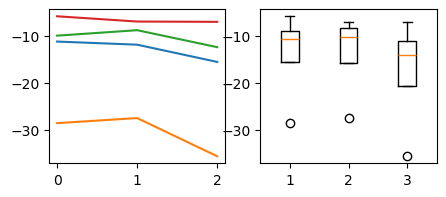

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(5, 2))
ax[0].plot(amps.T);
# ax[0].yscale('symlog', linthresh=0.1)  # <- используйте это!
ax[1].boxplot(amps);

In [21]:
# P60
tlim = [45, 75]
mask = get_mask(tlim, tvec)

epochs_peak = TEPs[:, :, mask, :]
amps = np.max(epochs_peak, axis=(2, 3))

amps

array([[20.255644, 19.943605, 19.957575],
       [21.337614, 20.454695, 24.441261],
       [13.456147, 15.627423, 14.409974],
       [ 8.325441,  8.950048,  8.646262]], dtype=float32)

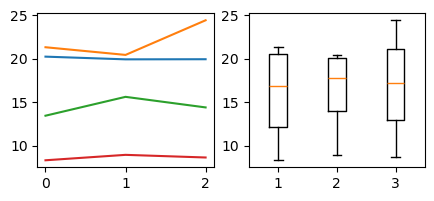

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(5, 2))
ax[0].plot(amps.T);
# ax[0].yscale('symlog', linthresh=0.1)  # <- используйте это!
ax[1].boxplot(amps);

In [23]:
# N100
tlim = [80, 110]
mask = get_mask(tlim, tvec)

epochs_peak = TEPs[:, :, mask, :]
amps = np.min(epochs_peak, axis=(2, 3))

amps

array([[-16.952148 , -12.812396 , -17.120264 ],
       [-11.234201 , -10.056853 , -12.145863 ],
       [ -9.276903 ,  -8.668571 , -12.02533  ],
       [ -6.829265 ,  -7.4685326,  -6.90788  ]], dtype=float32)

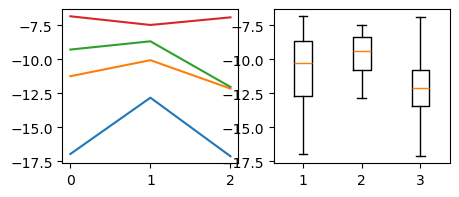

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(5, 2))
ax[0].plot(amps.T);
# ax[0].yscale('symlog', linthresh=0.1)  # <- используйте это!
ax[1].boxplot(amps);

# Усреднённые данные

In [25]:
TEPs.shape

(4, 3, 3501, 64)

In [26]:
# epochs = [[], [], []]

# for record in task_records:
#     filename = os.path.join(data_folder, record)
#     epochs_all, tvec, conds = get_data(filename)

#     before_mask, onset_mask, rest_mask = get_conditions_masks(conds)
#     epochs[0].append(np.mean(epochs_all[:, before_mask, :], axis=1))        
#     epochs[1].append(np.mean(epochs_all[:, onset_mask, :], axis=1))
#     epochs[2].append(np.mean(epochs_all[:, rest_mask, :], axis=1))
# epochs = np.array(epochs)
# epochs.shape

In [27]:
epochs_avr = np.mean(TEPs, axis=0)  # усреднение по людям
epochs_avr.shape

(3, 3501, 64)

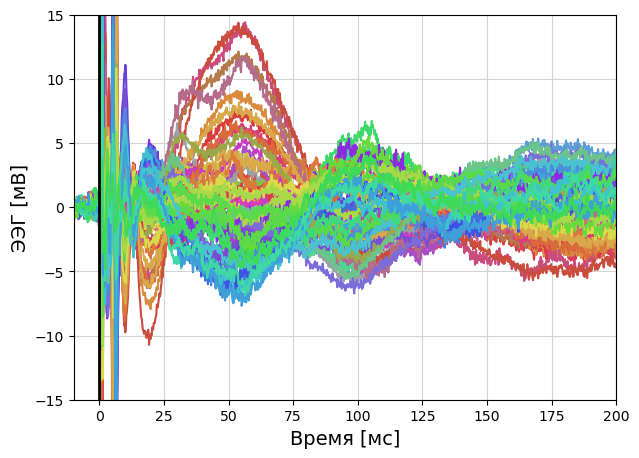

In [28]:
tmin, tmax = -10, 200
amp = 15

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
  
for color, TEP in zip(colors, epochs_avr[1].T): # начало движения
    ax.plot(tvec, TEP, color=color)
ax.set_xlim(tmin, tmax)
ax.set_ylim(-amp, amp)
ax.set_xlabel("Время [мс]", fontsize=14)
ax.set_ylabel("ЭЭГ [мВ]", fontsize=14)
ax.grid(color="lightgrey")

# ax.set_title('ТВП в М1 в момент выполнения движения', fontsize=18)

ax.axvline(0, color="black", linewidth=2)

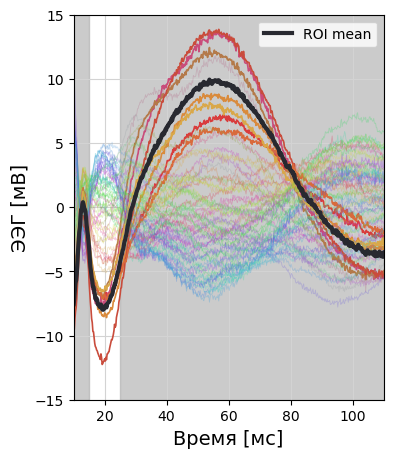

In [144]:
tmin, tmax = 10, 110
tlim = 15, 25
amp = 15

ROI_contra = ["C3", "CP3", "CP5", "CP1", "P5", "P3", "P1"]
ROI_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_contra]

alpha = np.array([0.3] * epochs_avr.shape[2])
alpha[ROI_idx] = 1

width = np.array([.6] * epochs_avr.shape[2])
width[ROI_idx] = 1.2

tep_avg_all = np.mean(epochs_avr, axis=0)
fig, ax = plt.subplots(1, 1, figsize=(4, 5))

lines = []
ch = 0
for color, TEP in zip(colors, tep_avg_all.T): # начало движения
    label = ROI_contra[ROI_idx.index(ch)] if ch in ROI_idx else None
    ax.plot(tvec, TEP, color=color, alpha=alpha[ch], linewidth=width[ch]) #, label=label)
    ch += 1

roi_tep = np.mean(tep_avg_all[:, ROI_idx], axis=1)
ax.plot(tvec, roi_tep, color="#282930", alpha=1, linewidth=3, label="ROI mean")

handles, labels = ax.get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l is not None]
if filtered:
    handles, labels = zip(*filtered)
    ax.legend(handles, labels, loc="best", frameon=True, fancybox=True)

ax.set_xlim(tmin, tmax)
ax.set_ylim(-amp, amp)
ax.set_xlabel("Время [мс]", fontsize=14)
ax.set_ylabel("ЭЭГ [мВ]", fontsize=14)
ax.grid(color="lightgrey")

# ax.fill_betweenx(ax.get_ylim(), tlim[1], tmax, color="grey", )
# ax.fill_betweenx(ax.get_ylim(), tlim[1], tmax, color="grey", )

a = 0.6
ax.axvspan(tmin, tlim[0], alpha=a, color='darkgrey', zorder=0)
ax.axvspan(tlim[1], tmax, alpha=a, color='darkgrey', zorder=0)

ax.axvline(0, color="black", linewidth=2)

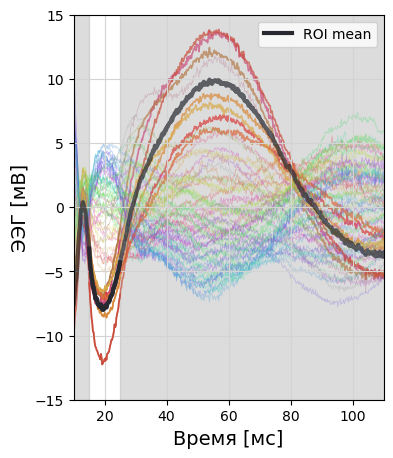

In [159]:
tmin, tmax = 10, 110
tlim = 15, 25
amp = 15

mask_interest = ((tvec >= tlim[0]) & (tvec <= tlim[1])).flatten()

ROI_contra = ["C3", "CP3", "CP5", "CP1", "P5", "P3", "P1"]
ROI_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_contra]

alpha = np.array([0.3] * epochs_avr.shape[2])
alpha[ROI_idx] = 1

width = np.array([.6] * epochs_avr.shape[2])
width[ROI_idx] = 1.2

tep_avg_all = np.mean(epochs_avr, axis=0)
fig, ax = plt.subplots(1, 1, figsize=(4, 5))

lines = []
ch = 0
for color, TEP in zip(colors, tep_avg_all.T): # начало движения
    label = ROI_contra[ROI_idx.index(ch)] if ch in ROI_idx else None
    if ch in ROI_idx:
        # Вся линия очень прозрачная
        ax.plot(tvec, TEP, color=color, alpha=0.7, linewidth=width[ch], zorder=1)
        # Только область интереса нормальная
        ax.plot(tvec[mask_interest], TEP[mask_interest], 
               color=color, alpha=alpha[ch], linewidth=width[ch], zorder=2)
    else:
        ax.plot(tvec, TEP, color=color, alpha=alpha[ch], linewidth=width[ch], zorder=1)

    # ax.plot(tvec, TEP, color=color, alpha=alpha[ch], linewidth=width[ch]) #, label=label)
    ch += 1

roi_tep = np.mean(tep_avg_all[:, ROI_idx], axis=1)
ax.plot(tvec, roi_tep, color="#282930", alpha=0.7, linewidth=3)
# Только область интереса нормальная
ax.plot(tvec[mask_interest], roi_tep[mask_interest], 
        color="#282930", alpha=1, linewidth=3, zorder=2, label="ROI mean")


handles, labels = ax.get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l is not None]
if filtered:
    handles, labels = zip(*filtered)
    ax.legend(handles, labels, loc="best", frameon=True, fancybox=True)

ax.set_xlim(tmin, tmax)
ax.set_ylim(-amp, amp)
ax.set_xlabel("Время [мс]", fontsize=14)
ax.set_ylabel("ЭЭГ [мВ]", fontsize=14)
ax.grid(color="lightgrey")

# ax.fill_betweenx(ax.get_ylim(), tlim[1], tmax, color="grey", )
# ax.fill_betweenx(ax.get_ylim(), tlim[1], tmax, color="grey", )

a = 0.4
ax.axvspan(tmin, tlim[0], alpha=a, color='darkgrey', zorder=0)
ax.axvspan(tlim[1], tmax, alpha=a, color='darkgrey', zorder=0)

ax.axvline(0, color="black", linewidth=2)

In [ ]:
mask_interest

(3501, 1)

ValueError: 'x' is not 1-dimensional

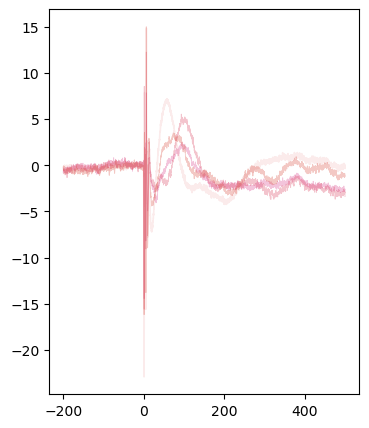

In [148]:
tmin, tmax = 10, 110
tlim = (15, 25)
amp = 15

ROI_contra = ["C3", "CP3", "CP5", "CP1", "P5", "P3", "P1"]
ROI_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_contra]

alpha = np.array([0.3] * epochs_avr.shape[2])
alpha[ROI_idx] = 1

width = np.array([.6] * epochs_avr.shape[2])
width[ROI_idx] = 1.2

tep_avg_all = np.mean(epochs_avr, axis=0)
fig, ax = plt.subplots(1, 1, figsize=(4, 5))

# Создаем маску для области интереса (где НЕ нужно делать прозрачным)
mask_interest = (tvec >= tlim[0]) & (tvec <= tlim[1])

ch = 0
for color, TEP in zip(colors, tep_avg_all.T):
    if ch in ROI_idx:
        # Рисуем основную линию
        line, = ax.plot(tvec, TEP, color=color, alpha=0.1, linewidth=width[ch], zorder=1)
        # Создаем эффект "вырезания" для области интереса
        ax.fill_between(tvec, TEP, where=mask_interest, color=color, 
                       alpha=alpha[ch], linewidth=0, zorder=2)
        ax.plot(tvec[mask_interest], TEP[mask_interest], 
               color=color, alpha=alpha[ch], linewidth=width[ch], zorder=2)
    else:
        ax.plot(tvec, TEP, color=color, alpha=alpha[ch], linewidth=width[ch], zorder=1)
    ch += 1

# Средняя линия ROI
roi_tep = np.mean(tep_avg_all[:, ROI_idx], axis=1)
ax.plot(tvec, roi_tep, color="#282930", alpha=0.2, linewidth=3, zorder=1)
ax.plot(tvec[mask_interest], roi_tep[mask_interest], 
       color="#282930", alpha=1, linewidth=3, zorder=2, label="ROI mean")

# Заливка фона
a = 0.6
ax.axvspan(tmin, tlim[0], alpha=a, color='darkgrey', zorder=0)
ax.axvspan(tlim[1], tmax, alpha=a, color='darkgrey', zorder=0)

ax.set_xlim(tmin, tmax)
ax.set_ylim(-amp, amp)
ax.set_xlabel("Время [мс]", fontsize=14)
ax.set_ylabel("ЭЭГ [мВ]", fontsize=14)
ax.grid(color="lightgrey")
ax.axvline(0, color="black", linewidth=2)

# Легенда
handles, labels = ax.get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l is not None]
if filtered:
    handles, labels = zip(*filtered)
    ax.legend(handles, labels, loc="best", frameon=True, fancybox=True)

plt.show()

In [112]:
tep_avg_all[:, ROI_idx].shape

(3501, 7)

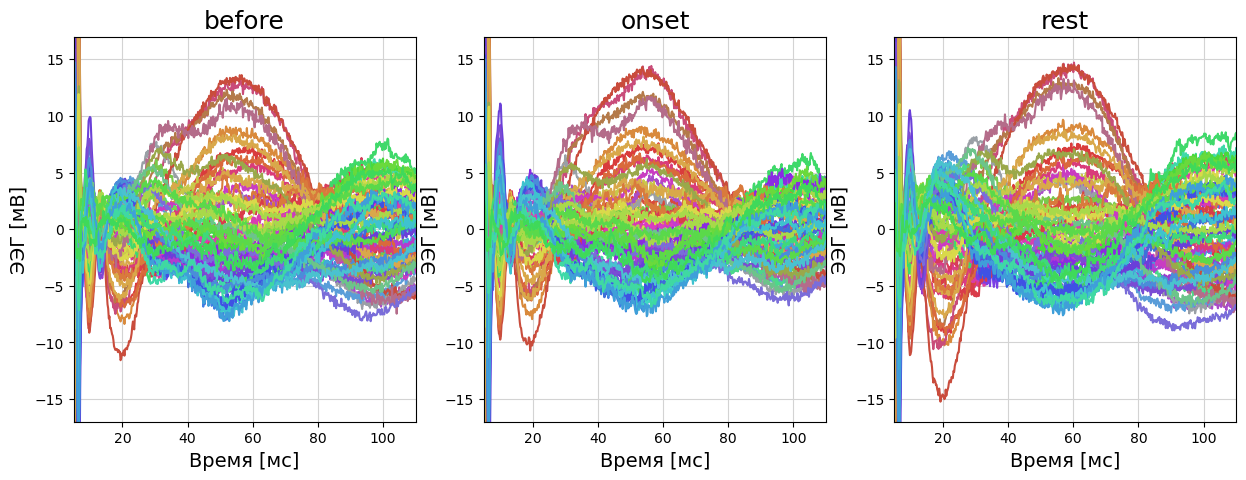

In [29]:
tmin, tmax = 5, 110
amp = 17

titles = ["before", "onset", "rest"]
fig, axis = plt.subplots(1, 3, figsize=(15, 5))

for i in [0, 1, 2]:
    ax = axis[i]
    for color, TEP in zip(colors, epochs_avr[i].T): # начало движения
        ax.plot(tvec, TEP, color=color)
    ax.set_xlim(tmin, tmax)
    ax.set_ylim(-amp, amp)
    # ax.set_ylim(0.45, 0.60)
    ax.set_xlabel("Время [мс]", fontsize=14)
    ax.set_ylabel("ЭЭГ [мВ]", fontsize=14)
    ax.grid(color="lightgrey")

    ax.set_title(titles[i], fontsize=18)

    ax.axvline(0, color="black", linewidth=2)

# fig.suptitle(f"Среднее по М1 РА")
# fig_filename = os.path.join(r"../results/fig16.04", f"teps_m1_avg.png")
# plt.savefig(fig_filename, dpi=300, bbox_inches="tight")

In [73]:
from matplotlib import colormaps as cm
from matplotlib.colors import ListedColormap
viridisBig = cm.get_cmap('jet')
newcmp = 'jet' #ListedColormap(viridisBig(np.linspace(0, 1, 35)))

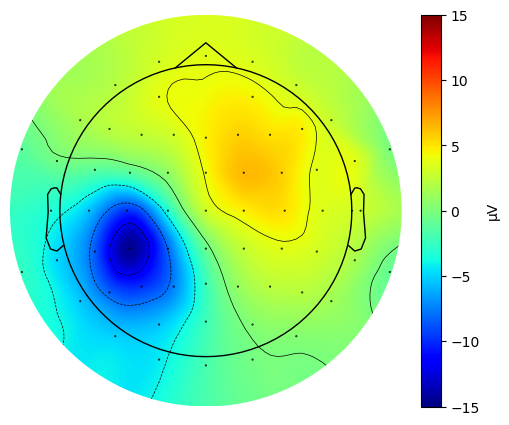

In [79]:
tlim = [19, 22]
mask = get_mask(tlim, tvec)
epochs_peak = np.mean(epochs_avr[2, mask, :], axis=0)

amp = 15
im, cn = plot_topomap(epochs_peak, positions,  ch_type='eeg',image_interp='cubic',  #names = ch_labels,axes=axis[j], 
                size=5, show=False, contours=5, sphere=0.5, cmap=newcmp, extrapolate='head', vlim=[-amp, amp])
# plt.colorbar(im)
cbar = plt.colorbar(im,  fraction=0.05, aspect=20) #ax=axis[j],
cbar.set_label('μV', fontsize=10)

# 3. Настройка внешнего вида осей
# plt.title(f'Condition 1', fontsize=12, fontweight='bold')
ax.set_facecolor('white')

In [39]:
epochs_peak.shape

(49, 64)

In [35]:
epochs_avr.shape

(3, 3501, 64)

In [30]:
epochs_avr.shape

(3, 3501, 64)

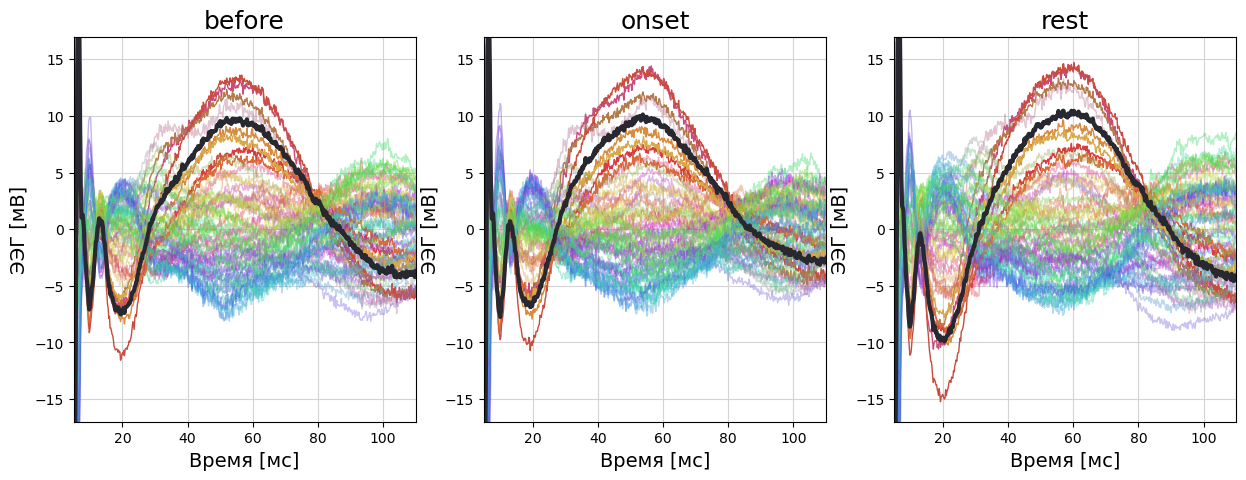

In [105]:
tmin, tmax = 5, 110
amp = 17
# N20!!!!!!!!!!!!!!!!!!!
titles = ["before", "onset", "rest"]
fig, axis = plt.subplots(1, 3, figsize=(15, 5))

ROI_contra = ["C3", "CP3", "CP5", "CP1", "P5", "P3", "P1"]
ROI_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_contra]

alpha= np.array([0.4] * epochs_avr.shape[2])
alpha[ROI_idx] = 1

for i in [0, 1, 2]:
    ax = axis[i]
    
    ch = 0
    for color, TEP in zip(colors, epochs_avr[i].T): # начало движения
        ax.plot(tvec, TEP, color=color, alpha=alpha[ch], linewidth=1)
        ch += 1
    
    roi_tep = np.mean(epochs_avr[i, :, ROI_idx], axis=0)
    ax.plot(tvec, roi_tep, color="#282930", alpha=1, linewidth=3)
    
    ax.set_xlim(tmin, tmax)
    ax.set_ylim(-amp, amp)
    # ax.set_ylim(0.45, 0.60)
    ax.set_xlabel("Время [мс]", fontsize=14)
    ax.set_ylabel("ЭЭГ [мВ]", fontsize=14)
    ax.grid(color="lightgrey")

    ax.set_title(titles[i], fontsize=18)

    ax.axvline(0, color="black", linewidth=2)

# fig.suptitle(f"Среднее по М1 РА")
# fig_filename = os.path.join(r"../results/fig16.04", f"teps_m1_avg_n20.png")
# plt.savefig(fig_filename, dpi=300, bbox_inches="tight")

In [ ]:
np.mean(epochs_avr[i, :, ROI_idx], axis=0).shape

(3501,)

In [88]:
epochs_avr[i, :, ROI_idx].shape

(7, 3501)

In [ ]:
# расчёты: 
# + скачать табличку - сессия, сет, задача, человек
# + находить записи одного типа
# усреднение записей по человеку с одной задачей (тоже сохранить?)
# нахождение пика для группы электродов в выделенном временном диапазоне
# определение для пика амплитуды, длительности, латентности
#

# визуализация: 
# бабочный график
# выделение на нём пика для группы электродов в выделенном временном диапазоне
# отрисовка топоплота
# отрисовка "статистики" (распределение/боксы) для амплитуды, длительности, латентности 

In [16]:
import h5py
def read_matlab_strings_correct(filepath, var_name):
    """Правильное чтение MATLAB string (новый тип) из .mat v7.3"""
    with File(filepath, 'r') as f:
        data = f["cleanedResult"][var_name]
        
        # MATLAB string хранится как dataset с атрибутами
        # или как массив ссылок на объекты с данными
        if data.dtype == np.dtype('O'):  # объектные ссылки
            strings = []
            # Проходим по всем элементам
            for idx in range(data.size):
                ref = data.flatten()[idx]
                if isinstance(ref, h5py.h5r.Reference):
                    # Получаем объект по ссылке
                    str_obj = f[ref]
                    # Читаем данные как байты
                    raw_data = str_obj[()]
                    
                    # MATLAB строки обычно UTF-16
                    if raw_data.dtype == np.uint16:
                        # Конвертируем числа в символы
                        chars = raw_data.flatten()
                        # Убираем нулевые символы в конце
                        chars = chars[chars != 0]
                        s = ''.join(chr(c) for c in chars)
                    elif raw_data.dtype == np.uint8:
                        s = raw_data.tobytes().decode('utf-8', errors='ignore')
                    else:
                        s = str(raw_data)
                    
                    strings.append(s)
                else:
                    strings.append(str(ref))
            
            # Если исходные данные были 2D, восстанавливаем форму
            if len(data.shape) == 2:
                strings = np.array(strings).reshape(data.shape)
            
            return strings
        else:
            return data[()]

# Использование
labels = read_matlab_strings_correct(filename, 'epoch_types')
print(labels)

[[3707764736          2          1          1          6          1]]


In [11]:
labels = read_mat73_variable(filename, 'epoch_types')
epochs = read_mat73_variable(filename, 'epochs_clean')

In [17]:
import hdf5storage
data = hdf5storage.loadmat(filename)

In [20]:
data["cleanedResult"]["epoch_types"]

array([[[3707764736,          2,          1,          1,          6,
                  1]]], dtype=uint32)